# Manifesto Similarity Analysis

Interactief notebook om de geaggregeerde beleidstopicvectoren en gelijkenissen tussen Nederlandse verkiezingsprogramma's te analyseren.

## Voorbereiding

1. Run eerst de classificatie (`analyze_manifestos.py`) zodat er JSON-voorspellingen in `verkiezingsprogrammas_predictions/` staan.
2. Draai daarna het samenvattingsscript:

```bash
python3 analyze_similarity.py --predictions-dir verkiezingsprogrammas_predictions --output-dir analysis
```

Dit notebook leest vervolgens alle bestanden uit `analysis/`.

In [ ]:
# !pip install seaborn

In [ ]:
from pathlib import Path
import json
from typing import Dict
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

DATA_DIR = Path("analysis")
TOPIC_FILE = DATA_DIR / "party_topic_vectors.parquet"
SIMILARITY_FILE = DATA_DIR / "party_similarity_matrix.csv"
CONTRIBUTION_FILE = DATA_DIR / "pairwise_contributions.json"

DATA_DIR

PosixPath('analysis')

In [ ]:
if not TOPIC_FILE.exists():
    raise FileNotFoundError(
        f"Topic-vectorbestand niet gevonden: {TOPIC_FILE}. Run analyze_similarity.py eerst."
    )

vectors = pd.read_parquet(TOPIC_FILE)
vectors.head()

,305 - Political Authority,202 - Democracy,303 - Governmental and Administrative Efficiency,601 - National Way of Life: Positive,606 - Civic Mindedness: Positive,404 - Economic Planning,301 - Federalism,416 - Anti-Growth Economy: Positive,501 - Environmental Protection: Positive,503 - Equality: Positive,...,106 - Peace,103 - Anti-Imperialism,413 - Nationalisation,105 - Military: Negative,109 - Internationalism: Negative,102 - Foreign Special Relationships: Negative,406 - Protectionism: Positive,407 - Protectionism: Negative,702 - Labour Groups: Negative,507 - Education Limitation
program,,,,,,,,,,,,,,,,,,,,,
50plus,0.031768,0.010331,0.040757,0.035892,0.013910,0.001874,0.005936,0.020099,0.024499,0.120875,...,0.000366,0.000360,0.002674,0.002779,0.001069,0.000044,0.000917,0.000407,0.000169,0.001478
bbb,0.042003,0.018770,0.043977,0.048320,0.024880,0.002803,0.033527,0.028140,0.056220,0.053657,...,0.003523,0.000672,0.002277,0.001796,0.007341,0.000234,0.008138,0.001639,0.000138,0.000908
cda,0.105585,0.015942,0.037272,0.023629,0.032990,0.002498,0.012755,0.032190,0.030618,0.043187,...,0.002606,0.000799,0.000790,0.001576,0.001237,0.000183,0.002251,0.000963,0.000116,0.000301
christenunie-cu,0.018659,0.012660,0.036813,0.015897,0.038934,0.001620,0.014700,0.063548,0.076186,0.084828,...,0.011229,0.002753,0.003478,0.003793,0.002162,0.000370,0.003844,0.000645,0.000082,0.000942
d66,0.046286,0.045155,0.033027,0.014350,0.016166,0.003623,0.011217,0.065265,0.078582,0.115149,...,0.004625,0.001758,0.001123,0.001376,0.001124,0.000208,0.001385,0.002028,0.000050,0.000516


## Cosine-gelijkenis

Visualiseer de gelijkenis tussen alle programma's.

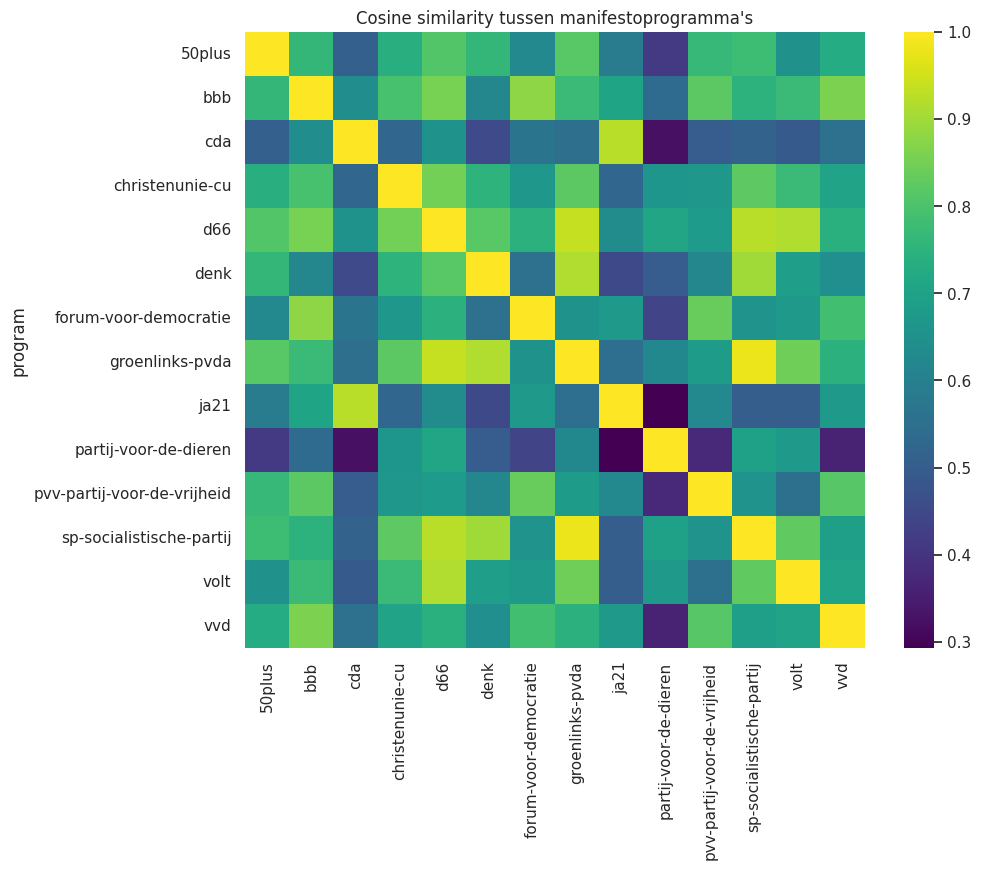

In [ ]:
if SIMILARITY_FILE.exists():
    similarity = pd.read_csv(SIMILARITY_FILE, index_col=0)
else:
    matrix = vectors.to_numpy(dtype=float)
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    normalized = matrix / norms
    similarity = pd.DataFrame(normalized @ normalized.T, index=vectors.index, columns=vectors.index)

plt.figure(figsize=(10, 8))
sns.heatmap(similarity, annot=False, cmap="viridis")
plt.title("Cosine similarity tussen manifestoprogramma's")
plt.show()

## Topiccorrelaties

Onderzoek welke onderwerpen sterk samen bewegen over partijen heen.


In [ ]:
topic_corr = vectors.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(topic_corr, cmap='coolwarm', center=0, square=True, cbar_kws={'label': 'Correlatie'})
plt.title('Correlatiematrix van topics (gemiddeld per partij)')
plt.show()

strong_threshold = 0.7
corr_no_diag = topic_corr.copy()
np.fill_diagonal(corr_no_diag.values, np.nan)
strong_mask = corr_no_diag.abs() > strong_threshold
strong_counts = strong_mask.sum().sort_values(ascending=False)
strong_counts.head(10)


## Principal Component Analysis (PCA)

Projecteer de partijprofielen op een lager-dimensionaal vlak om patronen te ontdekken.


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_vectors = scaler.fit_transform(vectors)

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(scaled_vectors)
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'], index=vectors.index)
variance_explained = pca.explained_variance_ratio_
print(f'Verklaarde variantie: PC1={variance_explained[0]:.2%}, PC2={variance_explained[1]:.2%}')

plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', s=80)
for label, (x, y) in pca_df.iterrows():
    plt.text(x + 0.03, y + 0.03, label, fontsize=9)
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.title('PCA van partij-topicvectoren')
plt.show()

## Top gelijkenissen per programma

Snippet om de meest vergelijkbare partners per programma te tonen.

In [ ]:
def top_matches(sim_matrix: pd.DataFrame, party: str, top_n: int = 5) -> pd.Series:
    row = sim_matrix.loc[party].drop(party)
    return row.sort_values(ascending=False).head(top_n)

example_party = similarity.index[0]
top_matches(similarity, example_party, top_n=5)

groenlinks-pvda                0.817633
d66                            0.808882
sp-socialistische-partij       0.778445
pvv-partij-voor-de-vrijheid    0.765729
bbb                            0.761228
Name: 50plus, dtype: float64

## Topic-bijdragen aan gelijkenis en verschil

Laad het JSON-bestand met contributies om te zien welke onderwerpen het meeste gewicht hebben in gelijkenis of verschil tussen twee partijen.

In [ ]:
if not CONTRIBUTION_FILE.exists():
    raise FileNotFoundError(
        f"Contributiebestand niet gevonden: {CONTRIBUTION_FILE}. Run analyze_similarity.py eerst."
    )

with CONTRIBUTION_FILE.open("r", encoding="utf-8") as handle:
    contribution_data = json.load(handle)

len(contribution_data)

91

In [ ]:
def inspect_pair(party_a: str, party_b: str, top_only: bool = True) -> Dict[str, object]:
    for entry in contribution_data:
        if {entry["party_a"], entry["party_b"]} == {party_a, party_b}:
            if top_only:
                return {
                    "similarity": entry["similarity"],
                    "shared_topics": entry["shared_topics"],
                    "topics_more_in_a": entry["topics_more_in_a"],
                    "topics_more_in_b": entry["topics_more_in_b"],
                }
            return entry
    raise ValueError(f"Partijcombinatie niet gevonden: {party_a} vs {party_b}")

first_pair = contribution_data[0]
inspect_pair(first_pair["party_a"], first_pair["party_b"])

{'similarity': 0.7612283692642424,
 'shared_topics': [{'topic': '504 - Welfare State Expansion',
   'contribution': 0.1838},
  {'topic': '411 - Technology and Infrastructure', 'contribution': 0.1383},
  {'topic': '503 - Equality: Positive', 'contribution': 0.1183},
  {'topic': '605 - Law and Order: Positive', 'contribution': 0.0641},
  {'topic': '303 - Governmental and Administrative Efficiency',
   'contribution': 0.0327}],
 'topics_more_in_a': [{'topic': '504 - Welfare State Expansion',
   'delta': 0.1266},
  {'topic': '503 - Equality: Positive', 'delta': 0.0672},
  {'topic': '706 - Non-economic Demographic Groups', 'delta': 0.0465},
  {'topic': '414 - Economic Orthodoxy', 'delta': 0.0229},
  {'topic': '605 - Law and Order: Positive', 'delta': 0.0191}],
 'topics_more_in_b': [{'topic': '703 - Agriculture and Farmers: Positive',
   'delta': -0.0351},
  {'topic': '501 - Environmental Protection: Positive', 'delta': -0.0317},
  {'topic': '411 - Technology and Infrastructure', 'delta': -0

Gebruik `inspect_pair("partij/a", "partij/b")` om zelf andere combinaties te analyseren.

Je kunt ook varianten maken die de `shared_topics` converteren naar een DataFrame voor verdere visualisatie of filtering.